# Планы и baseline


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option('display.max_columns', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (12, 4)

PROJECT_DIR = Path('/Users/sergey/PycharmProjects/WB_hackaton')
EDA_DIR = PROJECT_DIR / 'trash' / 'EDA'

OPT_PATH = EDA_DIR / 'dispatch_plan_agg.csv'
BASE_FULL_PATH = EDA_DIR / 'baseline_plan_agg.csv'
BASE_UNDER_RAW_PATH = EDA_DIR / 'baseline_underfill.csv'


## Загрузка


In [2]:
opt_df = pd.read_csv(OPT_PATH)
base_full_df = pd.read_csv(BASE_FULL_PATH)
base_under_raw_df = pd.read_csv(BASE_UNDER_RAW_PATH)

opt_df['timestamp'] = pd.to_datetime(opt_df['timestamp'])
base_full_df['timestamp'] = pd.to_datetime(base_full_df['timestamp'])
base_under_raw_df['timestamp'] = pd.to_datetime(base_under_raw_df['timestamp'])

print('opt', len(opt_df))
print('base_full', len(base_full_df))
print('base_under_raw', len(base_under_raw_df))


opt 20
base_full 20
base_under_raw 20


In [3]:
group_cols = ['warehouse_id', 'office_from_id', 'route_id', 'horizon', 'timestamp', 'distance_km']
num_sum = ['vehicles_count', 'cost_fixed', 'cost_underload', 'cost_wait', 'cost_total', 'empty_capacity_units']
num_first = ['demand_new', 'demand_carried_over', 'total_available', 'actually_shipped', 'leftover_stock']

def aggregate_plan(df: pd.DataFrame) -> pd.DataFrame:
    return (
        df.groupby(group_cols, as_index=False)
        .agg({**{c: 'sum' for c in num_sum}, **{c: 'first' for c in num_first}})
        .sort_values(['route_id', 'horizon'])
        .reset_index(drop=True)
    )

base_under_df = aggregate_plan(base_under_raw_df)


In [4]:
scenario_frames = {
    'opt': opt_df.copy(),
    'base_full': base_full_df.copy(),
    'base_under': base_under_df.copy(),
}

for name, df in scenario_frames.items():
    df['scenario'] = name

cmp_df = pd.concat(scenario_frames.values(), ignore_index=True)
display(cmp_df.head())


,warehouse_id,office_from_id,route_id,horizon,timestamp,distance_km,vehicles_count,cost_fixed,cost_underload,cost_wait,cost_total,empty_capacity_units,demand_new,demand_carried_over,total_available,actually_shipped,leftover_stock,scenario
0,w03,3,119,A: now,2025-05-30 10:30:00,12.00,13,"20,574.48",0.00,0.00,"20,574.48",0.00,178.00,0.00,178.00,178.00,0.00,opt
1,w03,3,119,B: +2h,2025-05-30 10:30:00,12.00,2,"3,213.60",50.00,0.00,"3,263.60",1.00,27.00,0.00,27.00,27.00,0.00,opt
2,w03,3,119,C: +4h,2025-05-30 10:30:00,12.00,3,"4,827.96",0.00,0.00,"4,827.96",0.00,39.00,0.00,39.00,39.00,0.00,opt
3,w03,3,119,D: +6h,2025-05-30 10:30:00,12.00,4,"5,722.64",20.00,0.00,"5,742.64",1.00,47.00,0.00,47.00,47.00,0.00,opt
4,w03,3,202,A: now,2025-05-30 10:30:00,22.00,12,"19,641.24",20.00,0.00,"19,661.24",1.00,159.00,0.00,159.00,159.00,0.00,opt


## Сводка


In [5]:
def scenario_summary(df: pd.DataFrame, name: str) -> pd.Series:
    demand_total = (df['demand_new'] + df['demand_carried_over']).sum()
    shipped = df['actually_shipped'].sum()
    return pd.Series({
        'scenario': name,
        'routes': df['route_id'].nunique(),
        'horizons': df['horizon'].nunique(),
        'demand_total': demand_total,
        'shipped': shipped,
        'leftover': df['leftover_stock'].sum(),
        'empty_cap': df['empty_capacity_units'].sum(),
        'cost_total': df['cost_total'].sum(),
        'cpu': df['cost_total'].sum() / shipped if shipped else np.nan,
        'fill_rate': shipped / demand_total if demand_total else np.nan,
    })

summary_df = pd.DataFrame([
    scenario_summary(opt_df, 'opt'),
    scenario_summary(base_full_df, 'base_full'),
    scenario_summary(base_under_df, 'base_under'),
])
display(summary_df)


,scenario,routes,horizons,demand_total,shipped,leftover,empty_cap,cost_total,cpu,fill_rate
0,opt,5,4,"1,702.00","1,702.00",0.00,13.00,"207,077.53",121.67,1.00
1,base_full,5,4,"1,702.00","1,702.00",0.00,44.00,"278,640.04",163.71,1.00
2,base_under,5,4,"1,702.00","1,638.00",64.00,0.00,"322,124.76",196.66,0.96


In [6]:
route_summary_df = (
    cmp_df.groupby(['scenario', 'route_id'], as_index=False)
    .agg(
        cost_total=('cost_total', 'sum'),
        shipped=('actually_shipped', 'sum'),
        leftover=('leftover_stock', 'sum'),
        empty_cap=('empty_capacity_units', 'sum'),
    )
)
display(route_summary_df.head(15))


,scenario,route_id,cost_total,shipped,leftover,empty_cap
0,base_full,119,"45,292.00",291.00,0.00,9.00
1,base_full,202,"77,200.32",459.00,0.00,9.00
2,base_full,209,"63,570.32",407.00,0.00,7.00
3,base_full,421,"45,702.20",282.00,0.00,12.00
4,base_full,852,"46,875.20",263.00,0.00,7.00
5,base_under,119,"55,903.04",276.00,15.00,0.00
6,base_under,202,"82,698.00",450.00,9.00,0.00
7,base_under,209,"76,073.20",390.00,17.00,0.00
8,base_under,421,"53,271.00",270.00,12.00,0.00
9,base_under,852,"54,179.52",252.00,11.00,0.00


## Стоимость


/var/folders/3_/tf8cx26n3p30t57pcfyv0d8w0000gn/T/ipykernel_8215/3047527048.py:7: UserWarning: Glyph 8381 (\N{RUBLE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/Users/sergey/PycharmProjects/WB_hackaton/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8381 (\N{RUBLE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


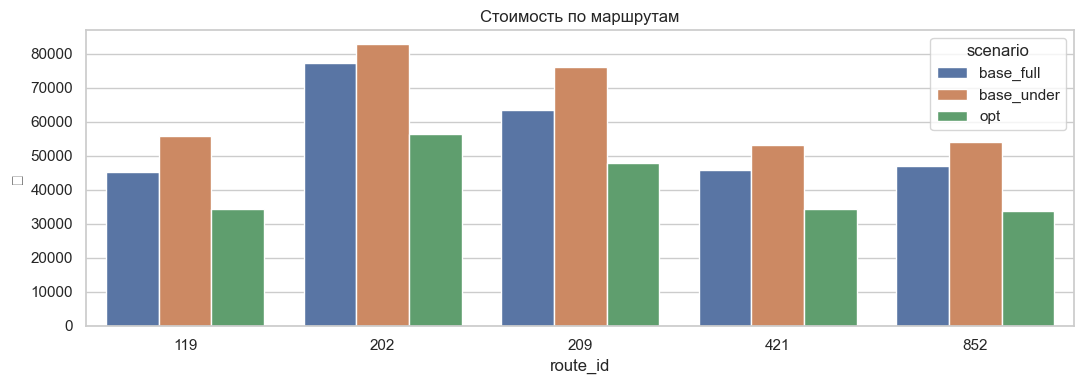

In [7]:
route_cost_df = cmp_df.groupby(['scenario', 'route_id'], as_index=False)['cost_total'].sum()
plt.figure(figsize=(11, 4))
sns.barplot(data=route_cost_df, x='route_id', y='cost_total', hue='scenario')
plt.title('Стоимость по маршрутам')
plt.ylabel('₽')
plt.xlabel('route_id')
plt.tight_layout()
plt.show()


/var/folders/3_/tf8cx26n3p30t57pcfyv0d8w0000gn/T/ipykernel_8215/3333721476.py:7: UserWarning: Glyph 8381 (\N{RUBLE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/Users/sergey/PycharmProjects/WB_hackaton/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8381 (\N{RUBLE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


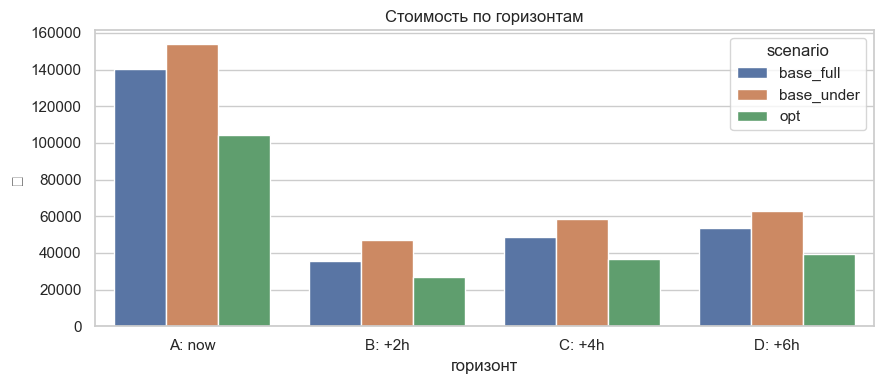

In [8]:
horizon_cost_df = cmp_df.groupby(['scenario', 'horizon'], as_index=False)['cost_total'].sum()
plt.figure(figsize=(9, 4))
sns.barplot(data=horizon_cost_df, x='horizon', y='cost_total', hue='scenario')
plt.title('Стоимость по горизонтам')
plt.ylabel('₽')
plt.xlabel('горизонт')
plt.tight_layout()
plt.show()


## Метрики


In [9]:
cpu_df = (
    cmp_df.groupby('scenario', as_index=False)
    .apply(lambda df: df['cost_total'].sum() / df['actually_shipped'].sum())
    .reset_index(name='cpu')
)
display(cpu_df)


TypeError: DataFrame.reset_index() got an unexpected keyword argument 'name'

In [ ]:
plt.figure(figsize=(6, 4))
sns.barplot(data=cpu_df, x='scenario', y='cpu')
plt.title('Стоимость на единицу')
plt.ylabel('₽ / ед.')
plt.xlabel('')
plt.tight_layout()
plt.show()


In [ ]:
fill_rate_df = (
    cmp_df.groupby('scenario', as_index=False)
    .apply(lambda df: df['actually_shipped'].sum() / (df['demand_new'] + df['demand_carried_over']).sum())
    .reset_index(name='fill_rate')
)
display(fill_rate_df)


In [ ]:
plt.figure(figsize=(6, 4))
sns.barplot(data=fill_rate_df, x='scenario', y='fill_rate')
plt.title('Fill rate')
plt.ylabel('доля')
plt.ylim(0, 1.05)
plt.xlabel('')
plt.tight_layout()
plt.show()


In [ ]:
shipped_df = cmp_df.groupby('scenario', as_index=False)['actually_shipped'].sum().rename(columns={'actually_shipped': 'shipped'})
display(shipped_df)


In [ ]:
plt.figure(figsize=(6, 4))
sns.barplot(data=shipped_df, x='scenario', y='shipped')
plt.title('Вывезено')
plt.ylabel('ед.')
plt.xlabel('')
plt.tight_layout()
plt.show()


## Остатки и ёмкость


In [ ]:
leftover_route_df = cmp_df.groupby(['scenario', 'route_id'], as_index=False)['leftover_stock'].sum()
plt.figure(figsize=(11, 4))
sns.barplot(data=leftover_route_df, x='route_id', y='leftover_stock', hue='scenario')
plt.title('Остаток по маршрутам')
plt.ylabel('ед.')
plt.xlabel('route_id')
plt.tight_layout()
plt.show()


In [ ]:
empty_cap_df = cmp_df.groupby('scenario', as_index=False)['empty_capacity_units'].sum()
display(empty_cap_df)


In [ ]:
plt.figure(figsize=(6, 4))
sns.barplot(data=empty_cap_df, x='scenario', y='empty_capacity_units')
plt.title('Пустая вместимость')
plt.ylabel('ед.')
plt.xlabel('')
plt.tight_layout()
plt.show()
